In [1]:
import pickle

# read the data

filename_int = "data/20250729_015746/data"
filename_no_int = "data/20250730_010858/data"

with open(filename_int, 'rb') as f:
    d_int = pickle.load(f)

with open(filename_no_int, 'rb') as f:
    d_no_int = pickle.load(f)

X = d_int['X']
Y = d_int['Y']
x, y = X[:,0], Y[0,:]
dx, dy = x[1] - x[0], y[1] - y[0]
V = d_no_int['V']
t_samples = d_int['t_samples']
ny = X.shape[1]

In [2]:
from scipy.ndimage import zoom
import numpy as np

def rescale_data(X, Y, V, n, factor_x, factor_y, xlim):

    x = X[:,0]
    ind_x = (x >= np.min(xlim)) & (x <= np.max(xlim))

    # get everything withing xlim
    X_cut = X[ind_x] 
    Y_cut = Y[ind_x]
    n_cut = n[:, ind_x]
    V_cut = V[:, ind_x]

    # Downsample X and Y to match
    X_ds = zoom(X_cut, (1/factor_x, 1/factor_y), order=1)
    Y_ds = zoom(Y_cut, (1/factor_x, 1/factor_y), order=1)
    V_ds = zoom(V_cut, (1/factor_y, 1/factor_x), order=1)
    n_ds = zoom(n_cut, (1/factor_y, 1/factor_x), order=1)

    return X_ds, Y_ds, V_ds, n_ds

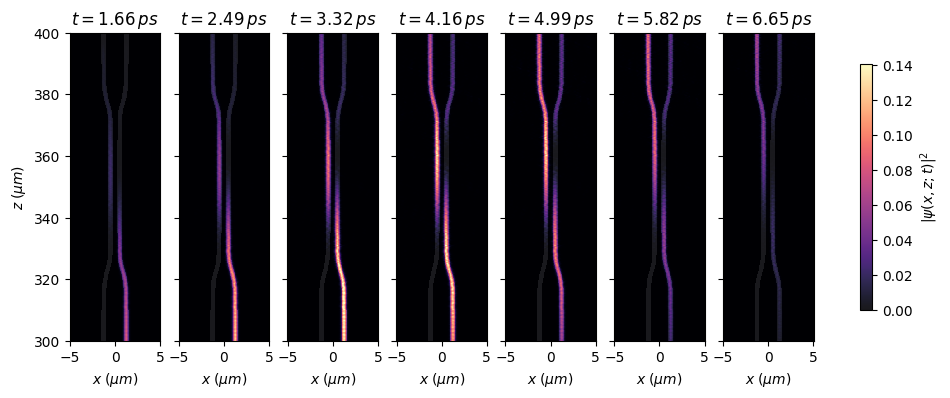

In [15]:
import matplotlib.pyplot as plt

dat = d_int["data"]
factor_x = 1.
factor_y = 1.
cmap = 'magma'

# plot_it = np.arange(2, len(t_samples), 2)
plot_it = np.array([2,3,4,5,6,7,8])

x_cut = 300
xlim = [x.min() + x_cut, x.max() - x_cut]

vmin, vmax = np.min(np.abs(dat[0]) ** 2), np.abs(np.max(dat[0]) ** 2)


density_up = []
density_down = []

fig, ax = plt.subplots(1,plot_it.size, figsize=(12,4))
it_plot = 0
mesh = None
for it, (t, psi) in enumerate(zip(t_samples, dat)):

        if it not in plot_it:
                continue

        # Compute |psi|^2 and downsample it with smoothing
        psi_density = np.abs(psi) ** 2

        density_up.append(psi_density[:ny//2].sum(axis=0) * dx)
        density_down.append(psi_density[ny//2:].sum(axis=0) * dx)
        
        X_ds, Y_ds, V_ds, psi_smoothed = rescale_data(X, Y, V, psi_density, factor_x, factor_y, xlim=xlim)

        ax[it_plot].pcolormesh(Y_ds, X_ds, V_ds.T, cmap='binary', alpha=1.)
        mesh = ax[it_plot].pcolormesh(Y_ds, X_ds, psi_smoothed.T, vmin=vmin, vmax=vmax, cmap=cmap, alpha=0.9)
        

        

        ax[it_plot].set_title(rf'$t={t:.2f}\,ps$', fontsize=12)
        ax[it_plot].set_xlabel(r'$x\; (\mu m)$',fontsize=10)
        if it_plot == 0:
                ax[it_plot].set_ylabel(r'$z\; (\mu m)$', fontsize=10)
        else:
                ax[it_plot].set_ylabel('')
                ax[it_plot].tick_params(labelleft=False)

        it_plot += 1

fig.colorbar(mesh, ax=ax, location='right', shrink=0.8, label=r'$|\psi(x,z;t)|^2$')

        
    

In [4]:
V[0,0]

np.float64(-151.98803355538374)

ratio: 0.7160547338141432
angle: 0.68\pi


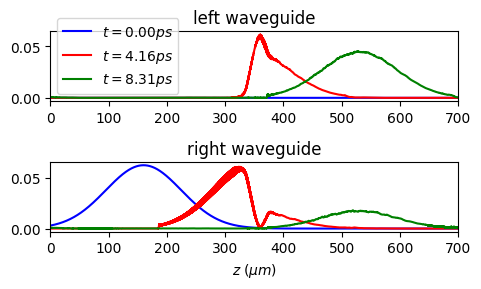

In [14]:
import matplotlib.pyplot as plt

dat = d_int["data"]
x_cut = 0
colors = ['b', 'r', 'g']

# plot_it = np.arange(2, len(t_samples), 2)
plot_it = np.array([0,5,10])


density_up = []
density_down = []
for it, (t, psi) in enumerate(zip(t_samples, dat)):

        if it not in plot_it:
                continue

        # Compute |psi|^2 and downsample it with smoothing
        psi_density = np.abs(psi) ** 2

        density_up.append(psi_density[:ny//2].sum(axis=0) * dx)
        density_down.append(psi_density[ny//2:].sum(axis=0) * dx)


fig, ax = plt.subplots(2,1,figsize=(5,3))
for ip, (n_up, n_down) in enumerate(zip(density_up, density_down)):
    ax[0].plot(x, n_up, color=colors[ip])
    ax[1].plot(x, n_down, color=colors[ip])

for a in ax:
        a.set_xlim([x.min() + x_cut, x.max() - x_cut])
        
ax[0].set_title('left waveguide')
ax[1].set_title('right waveguide')
ax[1].set_xlabel(r'$z\; (\mu m)$')
ax[0].tick_params(labelright=False)
ax[0].legend([rf"$t={t_samples[i]:.2f}ps$" for i in plot_it])
fig.tight_layout()

ratio = n_up.sum() / (n_up.sum() + n_down.sum())
print(f"ratio: {ratio}")
print(f"angle: {1. - np.asin(np.sqrt(ratio))/np.pi:.2f}\pi")

In [6]:
hbar_ueV = 6.582 * 1e2 # ps * ueV

w2 = np.abs(d_int['data'][0]) ** 2 / 10

U_ueV = 600 * (w2 ** 2).sum() * dx * dy
U_ps = U_ueV / hbar_ueV
U_gate = U_ps * t_samples[-1] / 4.

print(f"U ueV: {U_ueV:.4f}")
print(f"U ps-1: {U_ps:.4f}")
print(f"U gate 100 um: {U_gate:.4f}")

U ueV: 4.2936
U ps-1: 0.0065
U gate 100 um: 0.0136


In [20]:
sigma2 = 1
sigma_off = -0.0
sigma_diff = 0.1
num_channels = 5

Sigma = sigma_off * np.ones((5,5))
inds = range(num_channels)
Sigma[inds,inds] = sigma2

dSigma = sigma_diff * np.eye(num_channels)

Sigma_m1 = np.linalg.inv(Sigma)

np.trace(Sigma_m1 @ dSigma @ Sigma_m1 @ dSigma)

np.float64(0.05000000000000001)

# Homodyne FI

In [8]:
import numpy as np
import matplotlib.pyplot as plt

alpha = 1.
beta = 10.
phi = 1/2 * np.pi 
c = 0.5 * np.sqrt(1/2)

mu = c**2 * np.abs(alpha)**2 + (1-c**2) * np.abs(beta)**2 \
    + 2 * np.cos(phi) * c * np.sqrt(1-c**2) * np.abs(alpha) * np.abs(beta)

dmu_dt = 2 * np.sin(phi) * c * np.sqrt(1-c**2) * np.abs(alpha) * np.abs(beta)

FI = dmu_dt ** 2 / (mu + 1e-10)

print(rf"$\mu={mu:.2f}$")
print(rf"$d\mu/d\theta={dmu_dt:.2f}$")
print(rf"$FI={FI:.2f}$")

$\mu=87.62$
$d\mu/d\theta=6.61$
$FI=0.50$


In [40]:
np.exp(1j*phi)

np.complex128(6.123233995736766e-17+1j)

left, final 0.14696832183897557pi
right, final 0.11148321965139474pi


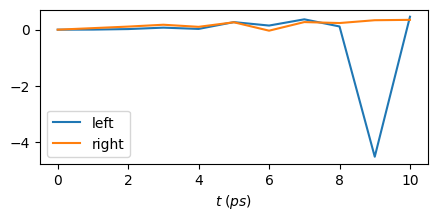

In [7]:
import matplotlib.pyplot as plt


x_cut = 0
colors = ['b', 'r', 'g']

# plot_it = np.arange(2, len(t_samples), 2)
plot_it = np.arange(len(t_samples))
k0_longitudinal = 26.25808785089985


angles_up = []
angles_down = []
for dat in [d_int['data'], d_no_int['data']]:

        density_up = []
        density_down = []
        angle_up = []
        angle_down = []
        for it, (t, psi) in enumerate(zip(t_samples, dat)):

                if it not in plot_it:
                        continue

                # Compute |psi|^2 and downsample it with smoothing
                psi_density = np.abs(psi) ** 2

                n_up, n_down = psi_density[:ny//2].sum(axis=0) * dy, psi_density[ny//2:].sum(axis=0) * dy
                phase_up, phase_down = (np.angle(np.exp(-1j * x * k0_longitudinal) * psi[:ny//2].mean(axis=0)),
                                        np.angle(np.exp(-1j * x * k0_longitudinal) * psi[ny//2:].mean(axis=0)))

                density_up.append(psi_density[:ny//2].sum() * dy)
                density_down.append(psi_density[ny//2:].sum() * dy)
                angle_up.append(np.average(phase_up, weights=np.where(n_up < 0.1 * n_up.max(), 0, n_up)))
                angle_down.append(np.average(phase_down, weights=np.where(n_down < 0.1 * n_down.max(), 0, n_down)))

        angles_up.append(angle_up)
        angles_down.append(angle_down)

plt.figure(figsize=(5,2))

diff_angle_up = np.array(angles_up[1]) - np.array(angles_up[0])
diff_angle_down = np.array(angles_down[1]) - np.array(angles_down[0])
plt.plot(diff_angle_up)
plt.plot(diff_angle_down)


        
plt.legend(['left', 'right'])
plt.xlabel(r'$t\; (ps)$')
plt.tick_params(labelright=False)
fig.show()

print(f"left, final {diff_angle_up[-1] / np.pi}pi")
print(f"right, final {diff_angle_down[-1] / np.pi}pi")

In [8]:
np.sum(n_up > 0.1 * n_up.max())

np.int64(5569)

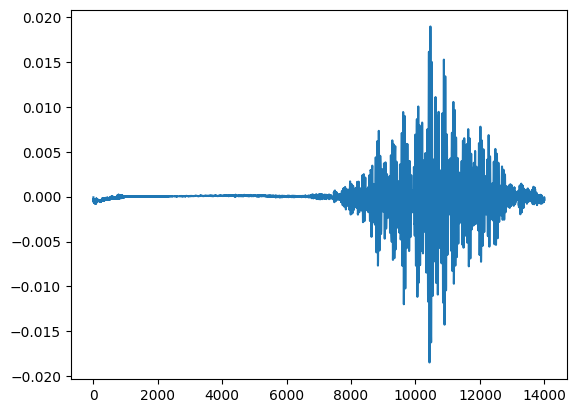

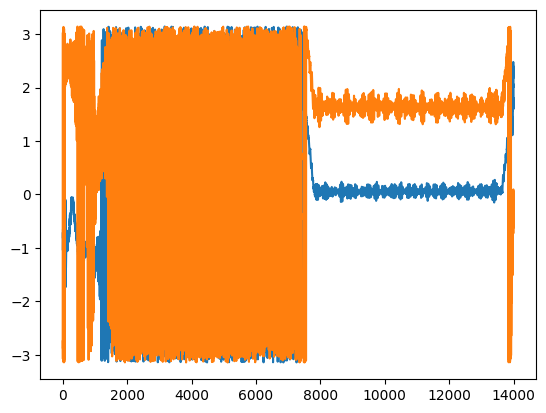

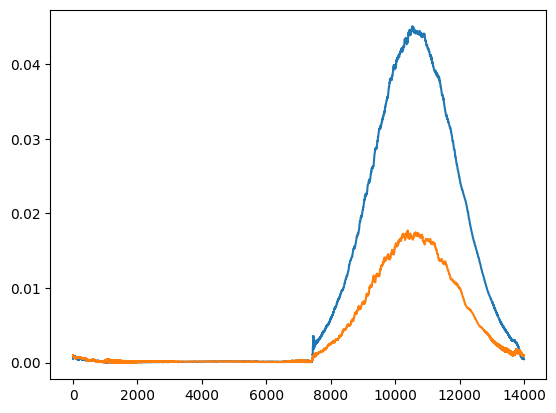

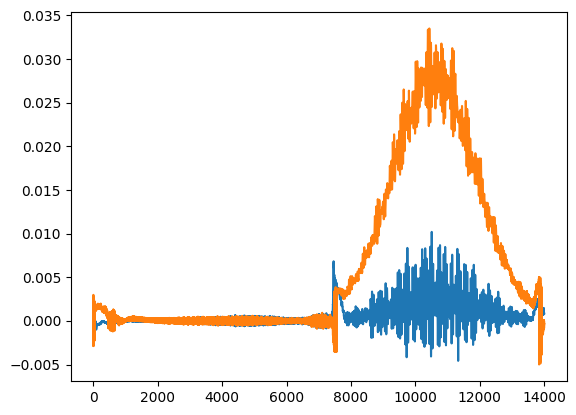

In [9]:
psi = d_no_int['data'][-1]

psi_density = np.abs(psi) ** 2

n_up, n_down = psi_density[:ny//2].sum(axis=0) * dy, psi_density[ny//2:].sum(axis=0) * dy
phase_up, phase_down = (np.angle(np.exp(-1j * x * k0_longitudinal) * psi[:ny//2].mean(axis=0)),
                        np.angle(np.exp(-1j * x * k0_longitudinal) * psi[ny//2:].mean(axis=0)))

plt.figure()
plt.plot(np.cos(phase_up-phase_down) * n_up)

plt.figure()
plt.plot(phase_up)
plt.plot(phase_down)

plt.figure()
plt.plot(n_up)
plt.plot(n_down)

plt.figure()
plt.plot(n_up * phase_up)
plt.plot(n_down * phase_down)

In [10]:
np.max(phase_up * n_up / n_up.sum())

np.float64(7.104002960192555e-05)

In [11]:
dat_int = d_int["data"]
dat_no_int = d_no_int["data"]
ind = -1

phase = lambda f: np.angle(f)

# plt.plot(x, np.cos(phase(dat_int[-1][ny//2:].sum(axis=0)) - phase(dat_no_int[-1][ny//2:].sum(axis=0))))
n_WG = 3.26
wavelength = 0.78
k0_longitudinal =  2 * np.pi * n_WG / wavelength
k0_longitudinal = 26.25808785089985


plt.figure()
plt.plot(x, np.exp(-1j * x * k0_longitudinal) * dat_no_int[ind][ny//2:].sum(axis=0))
plt.plot(x, np.exp(-1j * x * k0_longitudinal) * dat_int[ind][ny//2:].sum(axis=0))
# plt.plot(x, np.exp(-1j * x * k0_longitudinal) * dat_no_int[ind][ny//2:].sum(axis=0) - 
# np.exp(-1j * x * k0_longitudinal) * dat_int[ind][ny//2:].sum(axis=0))
plt.figure()
plt.plot(x, np.angle(np.exp(-1j * x * k0_longitudinal) * dat_no_int[ind][ny//2:].sum(axis=0)) * np.exp(-1j * x * k0_longitudinal) * np.abs(dat_no_int[ind][ny//2:].sum(axis=0))
plt.plot(x, np.angle(np.exp(-1j * x * k0_longitudinal) * dat_int[ind][ny//2:].sum(axis=0)) * np.exp(-1j * x * k0_longitudinal) * dat_no_int[ind][ny//2:].sum(axis=0))

plt.figure()
plt.plot(x, (np.abs(dat_no_int[ind][ny//2:]) ** 2).sum(axis=0))
plt.plot(x, (np.abs(dat_int[ind][ny//2:]) ** 2).sum(axis=0))


SyntaxError: '(' was never closed (2183590002.py, line 20)

In [ ]:
np.average([1, 1], weights=[123498, 234096])

np.float64(1.0)

np.float64(19.03760984717722)

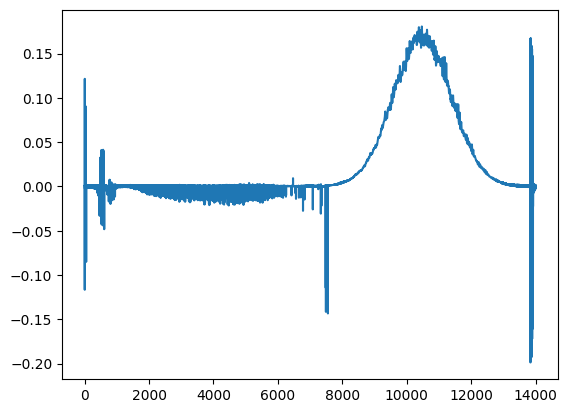

In [ ]:
f =     (
        np.angle(np.exp(-1j * x * k0_longitudinal) * dat_no_int[ind][ny//2:].sum(axis=0)) - 
        np.angle(np.exp(-1j * x * k0_longitudinal) * dat_int[ind][ny//2:].sum(axis=0))
    ) * (np.abs(dat_no_int[ind][ny//2:]) ** 2).sum(axis=0)

plt.plot(
    f
)

f.sum() * dy

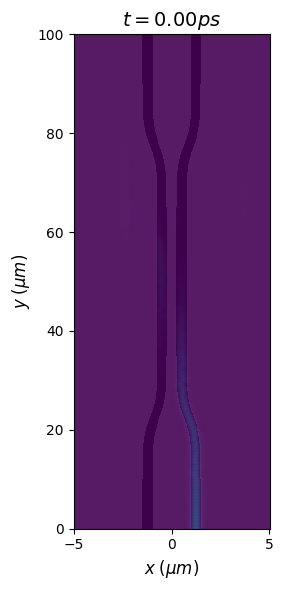

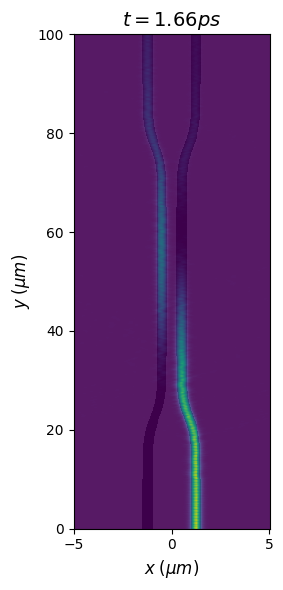

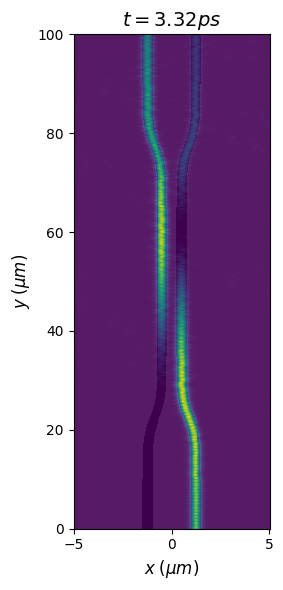

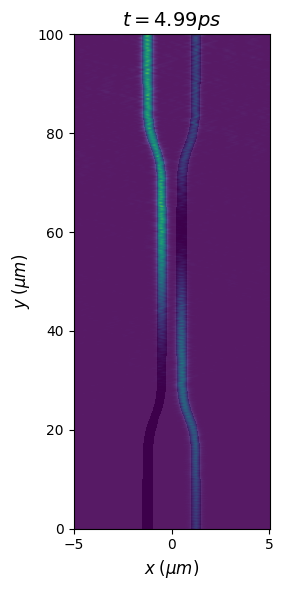

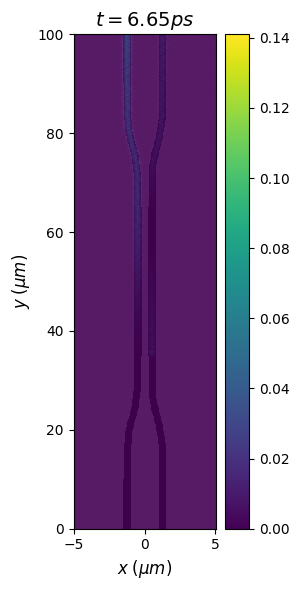

In [ ]:
import matplotlib.pyplot as plt

dat = d_int["data"]
factor_x = 1.
factor_y = 1.
cmap = 'viridis'

plot_it = np.arange(1, len(t_samples), 2)

x_cut = 300
xlim = [x.min() + x_cut, x.max() - x_cut]

vmin, vmax = np.min(np.abs(dat[0]) ** 2), np.abs(np.max(dat[0]) ** 2)


density_up = []
density_down = []

for it, (t, psi) in enumerate(zip(t_samples, dat)):

        if it not in plot_it:
                continue

        # Compute |psi|^2 and downsample it with smoothing
        psi_density = np.abs(psi) ** 2

        density_up.append(psi_density[:ny//2].sum(axis=0))
        density_down.append(psi_density[ny//2:].sum(axis=0))

        plt.figure(figsize=(3,6))
        X_ds, Y_ds, V_ds, psi_smoothed = rescale_data(X, Y, V, psi_density, factor_x, factor_y, xlim=xlim)

        plt.pcolormesh(Y_ds, X_ds, psi_smoothed.T, vmin=vmin, vmax=vmax, cmap=cmap)
        if it == plot_it[-1]:
                plt.colorbar()

        V_alpha = np.where(V == 0, 0, 0.2)
        plt.pcolormesh(Y_ds, X_ds, V_ds.T, cmap='gray', alpha=0.1)

        plt.title(rf'$t={t - t_samples[plot_it[0]]:.2f}\,ps$', fontsize=14)
        plt.xlabel(r'$x\; (\mu m)$',fontsize=12)
        plt.ylabel(r'$y\; (\mu m)$',fontsize=12)


        plt.tight_layout()
        
    

In [37]:
V_ds.shape

(3, 10001)

In [40]:
X.shape

(14001, 201)

In [2]:
import torch

T = torch.rand((100,100,100))